In [1]:
import pandas as pd
import numpy as np
import json
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('default')
sns.set_palette("husl")

print("✓ Imports successful")
print(f"Data location: /Users/leis/Documents/GitHub/DKRL-LLM/Real-Data-with-features/MIND/MINDsmall_train/")


✓ Imports successful
Data location: /Users/leis/Documents/GitHub/DKRL-LLM/Real-Data-with-features/MIND/MINDsmall_train/


In [ ]:
def load_embeddings(embedding_file):
    """Load embeddings from .vec file format"""
    embeddings = {}
    with open(embedding_file, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            entity_id = parts[0]
            vector = np.array([float(x) for x in parts[1:]])
            embeddings[entity_id] = vector
    return embeddings

# Load entity and relation embeddings
print("Loading entity embeddings...")
entity_embeddings = load_embeddings('MINDsmall_train/entity_embedding.vec')
print(f"✓ Loaded {len(entity_embeddings)} entity embeddings")

print("Loading relation embeddings...")
relation_embeddings = load_embeddings('MINDsmall_train/relation_embedding.vec')
print(f"✓ Loaded {len(relation_embeddings)} relation embeddings")

# Check embedding dimensions
sample_entity = list(entity_embeddings.keys())[0]
sample_relation = list(relation_embeddings.keys())[0]
print(f"Entity embedding dimension: {len(entity_embeddings[sample_entity])}")
print(f"Relation embedding dimension: {len(relation_embeddings[sample_relation])}")
print(f"Sample entity: {sample_entity}")
print(f"Sample relation: {sample_relation}")


Loading entity embeddings...
✓ Loaded 26904 entity embeddings
Loading relation embeddings...
✓ Loaded 1091 relation embeddings
Entity embedding dimension: 100
Relation embedding dimension: 100
Sample entity: Q41
Sample relation: P31


In [ ]:
def parse_entities(entity_str):
    """Parse entity JSON string and extract WikidataIds"""
    if pd.isna(entity_str) or entity_str == '[]':
        return []
    try:
        entities = json.loads(entity_str)
        return [entity['WikidataId'] for entity in entities if 'WikidataId' in entity]
    except:
        return []

# Load news data
print("Loading news data...")
news_columns = ['NewsID', 'Category', 'SubCategory', 'Title', 'Abstract', 'URL', 'TitleEntities', 'AbstractEntities']
news_df = pd.read_csv('MINDsmall_train/news.tsv', sep='\t', header=None, names=news_columns)

print(f"✓ Loaded {len(news_df)} news articles")
print(f"News columns: {news_df.columns.tolist()}")

# Parse entities from title and abstract
print("Parsing entities from news articles...")
news_df['title_entities'] = news_df['TitleEntities'].apply(parse_entities)
news_df['abstract_entities'] = news_df['AbstractEntities'].apply(parse_entities)

# Combine all entities for each news article
news_df['all_entities'] = news_df['title_entities'] + news_df['abstract_entities']

# Show sample data
print("\nSample news data:")
sample_news = news_df.iloc[0]
print(f"NewsID: {sample_news['NewsID']}")
print(f"Title: {sample_news['Title'][:100]}...")
print(f"Title entities: {sample_news['title_entities']}")
print(f"Abstract entities: {sample_news['abstract_entities']}")
print(f"Total entities: {len(sample_news['all_entities'])}")


Loading news data...
✓ Loaded 51282 news articles
News columns: ['NewsID', 'Category', 'SubCategory', 'Title', 'Abstract', 'URL', 'TitleEntities', 'AbstractEntities']
Parsing entities from news articles...

Sample news data:
NewsID: N55528
Title: The Brands Queen Elizabeth, Prince Charles, and Prince Philip Swear By...
Title entities: ['Q80976', 'Q43274', 'Q9682']
Abstract entities: []
Total entities: 3


In [ ]:
def create_news_embedding(entities, entity_embeddings, method='mean'):
    """
    Create news embedding by aggregating entity embeddings
    
    Args:
        entities: List of entity IDs
        entity_embeddings: Dictionary of entity embeddings
        method: Aggregation method ('mean', 'sum', 'max')
    
    Returns:
        News embedding vector
    """
    if not entities:
        # Return zero vector if no entities
        return np.zeros(100)
    
    # Get embeddings for entities that exist in our embedding dictionary
    valid_embeddings = []
    for entity in entities:
        if entity in entity_embeddings:
            valid_embeddings.append(entity_embeddings[entity])
    
    if not valid_embeddings:
        return np.zeros(100)
    
    embeddings_matrix = np.array(valid_embeddings)
    
    if method == 'mean':
        return np.mean(embeddings_matrix, axis=0)
    elif method == 'sum':
        return np.sum(embeddings_matrix, axis=0)
    elif method == 'max':
        return np.max(embeddings_matrix, axis=0)
    else:
        raise ValueError("Method must be 'mean', 'sum', or 'max'")

# Create embeddings for all news articles
print("Creating news embeddings...")
news_embeddings = {}
entity_coverage_stats = []

for idx, row in news_df.iterrows():
    news_id = row['NewsID']
    entities = row['all_entities']
    
    # Create embedding
    embedding = create_news_embedding(entities, entity_embeddings, method='mean')
    news_embeddings[news_id] = embedding
    
    # Track coverage statistics
    total_entities = len(entities)
    valid_entities = sum(1 for e in entities if e in entity_embeddings)
    coverage = valid_entities / total_entities if total_entities > 0 else 0
    entity_coverage_stats.append({
        'news_id': news_id,
        'total_entities': total_entities,
        'valid_entities': valid_entities,
        'coverage': coverage
    })

print(f"✓ Created embeddings for {len(news_embeddings)} news articles")

# Analyze entity coverage
coverage_df = pd.DataFrame(entity_coverage_stats)
print(f"\nEntity Coverage Statistics:")
print(f"Average entities per article: {coverage_df['total_entities'].mean():.2f}")
print(f"Average valid entities per article: {coverage_df['valid_entities'].mean():.2f}")
print(f"Average coverage: {coverage_df['coverage'].mean():.2%}")
print(f"Articles with no entities: {sum(coverage_df['total_entities'] == 0)}")
print(f"Articles with no valid entities: {sum(coverage_df['valid_entities'] == 0)}")


Creating news embeddings...
✓ Created embeddings for 51282 news articles

Entity Coverage Statistics:
Average entities per article: 3.03
Average valid entities per article: 2.99
Average coverage: 85.53%
Articles with no entities: 6798
Articles with no valid entities: 7020


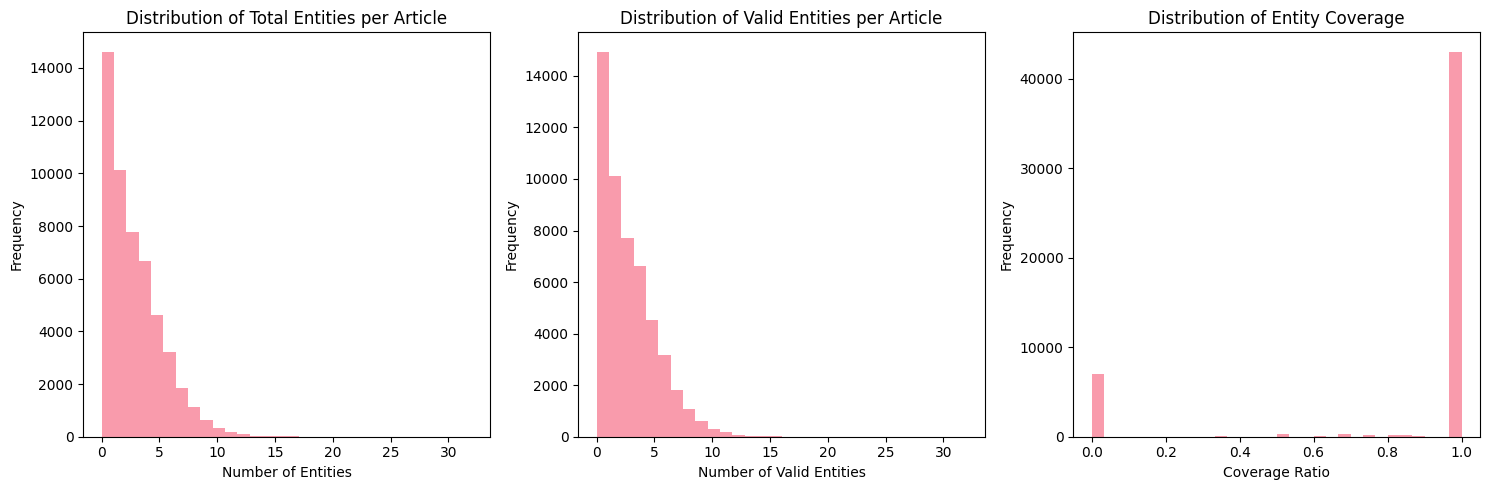


Entity statistics by news category:
               total_entities  valid_entities  coverage
Category                                               
autos                   2.207           2.140     0.783
entertainment           2.385           2.356     0.753
finance                 2.189           2.141     0.755
foodanddrink            1.902           1.853     0.740
health                  1.270           1.236     0.576
kids                    1.647           1.647     0.529
lifestyle               1.717           1.680     0.680
middleeast              6.000           6.000     1.000
movies                  3.365           3.338     0.825
music                   3.822           3.792     0.918
news                    3.182           3.144     0.892
northamerica            7.000           7.000     1.000
sports                  3.810           3.794     0.935
travel                  2.650           2.609     0.824
tv                      3.170           3.128     0.891
video      

In [ ]:
# Visualize entity coverage distribution
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(coverage_df['total_entities'], bins=30, alpha=0.7)
plt.title('Distribution of Total Entities per Article')
plt.xlabel('Number of Entities')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(coverage_df['valid_entities'], bins=30, alpha=0.7)
plt.title('Distribution of Valid Entities per Article')
plt.xlabel('Number of Valid Entities')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.hist(coverage_df['coverage'], bins=30, alpha=0.7)
plt.title('Distribution of Entity Coverage')
plt.xlabel('Coverage Ratio')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Analyze by category
category_stats = news_df.merge(coverage_df, left_on='NewsID', right_on='news_id')
category_analysis = category_stats.groupby('Category').agg({
    'total_entities': 'mean',
    'valid_entities': 'mean',
    'coverage': 'mean'
}).round(3)

print("\nEntity statistics by news category:")
print(category_analysis)


In [ ]:
def parse_history(history_str):
    """Parse history string into list of news IDs"""
    if pd.isna(history_str):
        return []
    return history_str.split()

def parse_impressions(impressions_str):
    """Parse impressions string into list of (news_id, label) tuples"""
    if pd.isna(impressions_str):
        return []
    
    impressions = []
    for item in impressions_str.split():
        parts = item.split('-')
        if len(parts) == 2:
            news_id, label = parts
            impressions.append((news_id, int(label)))
    return impressions

# Load behavior data
print("Loading behavior data...")
behavior_columns = ['ImpressionID', 'UserID', 'Time', 'History', 'Impressions']
behavior_df = pd.read_csv('MINDsmall_train/behaviors.tsv', sep='\t', header=None, names=behavior_columns)

print(f"✓ Loaded {len(behavior_df)} behavior records")

# Parse history and impressions
print("Parsing behavior data...")
behavior_df['history_list'] = behavior_df['History'].apply(parse_history)
behavior_df['impressions_list'] = behavior_df['Impressions'].apply(parse_impressions)

# Calculate statistics
behavior_df['history_length'] = behavior_df['history_list'].apply(len)
behavior_df['impression_count'] = behavior_df['impressions_list'].apply(len)
behavior_df['clicks'] = behavior_df['impressions_list'].apply(lambda x: sum(1 for _, label in x if label == 1))
behavior_df['ctr'] = behavior_df['clicks'] / behavior_df['impression_count']

print(f"\nBehavior Statistics:")
print(f"Average history length: {behavior_df['history_length'].mean():.2f}")
print(f"Average impressions per session: {behavior_df['impression_count'].mean():.2f}")
print(f"Average clicks per session: {behavior_df['clicks'].mean():.2f}")
print(f"Average CTR: {behavior_df['ctr'].mean():.3%}")

# Show sample
sample_behavior = behavior_df.iloc[0]
print(f"\nSample behavior:")
print(f"UserID: {sample_behavior['UserID']}")
print(f"History length: {sample_behavior['history_length']}")
print(f"Sample history: {sample_behavior['history_list'][:5]}")
print(f"Impressions: {sample_behavior['impression_count']}")
print(f"Clicks: {sample_behavior['clicks']}")
print(f"CTR: {sample_behavior['ctr']:.3%}")


Loading behavior data...
✓ Loaded 156965 behavior records
Parsing behavior data...

Behavior Statistics:
Average history length: 32.54
Average impressions per session: 37.23
Average clicks per session: 1.51
Average CTR: 10.854%

Sample behavior:
UserID: U13740
History length: 9
Sample history: ['N55189', 'N42782', 'N34694', 'N45794', 'N18445']
Impressions: 2
Clicks: 1
CTR: 50.000%


In [ ]:
def create_user_embedding(history_news_ids, news_embeddings, method='mean'):
    """
    Create user embedding by aggregating embeddings of news in history
    
    Args:
        history_news_ids: List of news IDs in user's history
        news_embeddings: Dictionary of news embeddings
        method: Aggregation method ('mean', 'sum', 'max')
    
    Returns:
        User embedding vector
    """
    if not history_news_ids:
        return np.zeros(100)
    
    # Get embeddings for news that exist in our embedding dictionary
    valid_embeddings = []
    for news_id in history_news_ids:
        if news_id in news_embeddings:
            valid_embeddings.append(news_embeddings[news_id])
    
    if not valid_embeddings:
        return np.zeros(100)
    
    embeddings_matrix = np.array(valid_embeddings)
    
    if method == 'mean':
        return np.mean(embeddings_matrix, axis=0)
    elif method == 'sum':
        return np.sum(embeddings_matrix, axis=0)
    elif method == 'max':
        return np.max(embeddings_matrix, axis=0)
    else:
        raise ValueError("Method must be 'mean', 'sum', or 'max'")

# Create user embeddings
print("Creating user embeddings from behavior history...")
user_embeddings = {}
user_coverage_stats = []

for idx, row in behavior_df.iterrows():
    user_id = row['UserID']
    history = row['history_list']
    
    # Create user embedding
    embedding = create_user_embedding(history, news_embeddings, method='mean')
    user_embeddings[user_id] = embedding
    
    # Track coverage statistics
    total_history = len(history)
    valid_history = sum(1 for news_id in history if news_id in news_embeddings)
    coverage = valid_history / total_history if total_history > 0 else 0
    
    user_coverage_stats.append({
        'user_id': user_id,
        'total_history': total_history,
        'valid_history': valid_history,
        'coverage': coverage
    })

print(f"✓ Created embeddings for {len(user_embeddings)} unique users")

# Analyze user embedding coverage
user_coverage_df = pd.DataFrame(user_coverage_stats)
print(f"\nUser Embedding Coverage Statistics:")
print(f"Average history items per user: {user_coverage_df['total_history'].mean():.2f}")
print(f"Average valid history items per user: {user_coverage_df['valid_history'].mean():.2f}")
print(f"Average coverage: {user_coverage_df['coverage'].mean():.2%}")
print(f"Users with no history: {sum(user_coverage_df['total_history'] == 0)}")
print(f"Users with no valid history: {sum(user_coverage_df['valid_history'] == 0)}")


Creating user embeddings from behavior history...
✓ Created embeddings for 50000 unique users

User Embedding Coverage Statistics:
Average history items per user: 32.54
Average valid history items per user: 32.54
Average coverage: 97.94%
Users with no history: 3238
Users with no valid history: 3238


In [ ]:
def cosine_similarity(vec1, vec2):
    """Calculate cosine similarity between two vectors"""
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    if norm1 == 0 or norm2 == 0:
        return 0
    return np.dot(vec1, vec2) / (norm1 * norm2)

def recommend_news(user_id, user_embeddings, news_embeddings, news_df, top_k=5):
    """
    Recommend news articles for a user based on embedding similarity
    
    Args:
        user_id: User ID
        user_embeddings: Dictionary of user embeddings
        news_embeddings: Dictionary of news embeddings
        news_df: News dataframe
        top_k: Number of recommendations
    
    Returns:
        List of recommended news with similarity scores
    """
    if user_id not in user_embeddings:
        return []
    
    user_embedding = user_embeddings[user_id]
    similarities = []
    
    for news_id, news_embedding in news_embeddings.items():
        similarity = cosine_similarity(user_embedding, news_embedding)
        similarities.append((news_id, similarity))
    
    # Sort by similarity and get top-k
    similarities.sort(key=lambda x: x[1], reverse=True)
    top_similarities = similarities[:top_k]
    
    # Add news information
    recommendations = []
    for news_id, similarity in top_similarities:
        news_info = news_df[news_df['NewsID'] == news_id].iloc[0]
        recommendations.append({
            'news_id': news_id,
            'similarity': similarity,
            'title': news_info['Title'],
            'category': news_info['Category'],
            'subcategory': news_info['SubCategory']
        })
    
    return recommendations

# Example recommendation
sample_user = behavior_df.iloc[0]['UserID']
recommendations = recommend_news(sample_user, user_embeddings, news_embeddings, news_df, top_k=5)

print(f"Top 5 recommendations for user {sample_user}:")
for i, rec in enumerate(recommendations, 1):
    print(f"{i}. [{rec['category']}/{rec['subcategory']}] {rec['title'][:80]}...")
    print(f"   Similarity: {rec['similarity']:.4f}")
    print()


Top 5 recommendations for user U13740:
1. [news/newspolitics] President Trump to speak at international police chiefs' conference in Chicago...
   Similarity: 0.8721

2. [news/newspolitics] Former U.S. Sen. Kay Hagan, of North Carolina, dies at 66...
   Similarity: 0.8604

3. [news/newspolitics] Former U.S. Sen. Kay Hagan, of North Carolina, dies at 66...
   Similarity: 0.8604

4. [news/newspolitics] Trump soaks in Deep South cheers at college football matchup...
   Similarity: 0.8588

5. [sports/baseball_mlb_videos] Trump welcomes Washington Nationals to White House, jokes about impeachment inqu...
   Similarity: 0.8574



In [13]:
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.model_selection import train_test_split

def prepare_click_prediction_data(behavior_df, user_embeddings, news_embeddings):
    """
    Prepare data for click prediction using embedding similarities
    """
    features = []
    labels = []
    
    for idx, row in behavior_df.iterrows():
        user_id = row['UserID']
        impressions = row['impressions_list']
        
        if user_id not in user_embeddings:
            continue
            
        user_embedding = user_embeddings[user_id]
        
        for news_id, label in impressions:
            if news_id in news_embeddings:
                news_embedding = news_embeddings[news_id]
                similarity = cosine_similarity(user_embedding, news_embedding)
                features.append([similarity])
                labels.append(label)
    
    return np.array(features), np.array(labels)

# Prepare data for click prediction
print("Preparing click prediction data...")
X, y = prepare_click_prediction_data(behavior_df[:1000], user_embeddings, news_embeddings)  # Use subset for demo
print(f"✓ Prepared {len(X)} samples")
print(f"Positive samples: {sum(y)} ({sum(y)/len(y):.2%})")

# Simple threshold-based prediction
def predict_clicks(similarities, threshold=0.1):
    """Predict clicks based on similarity threshold"""
    return (similarities > threshold).astype(int)

# Evaluate different thresholds
thresholds = np.arange(0.0, 0.5, 0.05)
results = []

for threshold in thresholds:
    predictions = predict_clicks(X.flatten(), threshold)
    
    # Calculate metrics
    if len(np.unique(predictions)) > 1:  # Avoid AUC error when all predictions are the same
        auc = roc_auc_score(y, X.flatten())
        accuracy = (predictions == y).mean()
        precision = (predictions * y).sum() / predictions.sum() if predictions.sum() > 0 else 0
        recall = (predictions * y).sum() / y.sum() if y.sum() > 0 else 0
        
        results.append({
            'threshold': threshold,
            'auc': auc,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall
        })

results_df = pd.DataFrame(results)
print("\nClick Prediction Results:")
print(results_df.head(10))

# Find best threshold
if not results_df.empty:
    best_idx = results_df['auc'].idxmax()
    best_result = results_df.iloc[best_idx]
    print(f"\nBest AUC: {best_result['auc']:.4f} at threshold {best_result['threshold']:.3f}")
    print(f"Accuracy: {best_result['accuracy']:.4f}")
    print(f"Precision: {best_result['precision']:.4f}")
    print(f"Recall: {best_result['recall']:.4f}")


Preparing click prediction data...
✓ Prepared 38109 samples
Positive samples: 1467 (3.85%)

Click Prediction Results:
   threshold       auc  accuracy  precision    recall
0       0.00  0.576267  0.286809   0.042133  0.806408
1       0.05  0.576267  0.303340   0.042566  0.795501
2       0.10  0.576267  0.324910   0.042851  0.775051
3       0.15  0.576267  0.352856   0.043459  0.752556
4       0.20  0.576267  0.387835   0.044390  0.725971
5       0.25  0.576267  0.427694   0.045083  0.687117
6       0.30  0.576267  0.471962   0.045950  0.643490
7       0.35  0.576267  0.521215   0.046391  0.584867
8       0.40  0.576267  0.575061   0.048445  0.538514
9       0.45  0.576267  0.627988   0.049291  0.473756

Best AUC: 0.5763 at threshold 0.000
Accuracy: 0.2868
Precision: 0.0421
Recall: 0.8064
